# SeaAlert - Notebook 08: Cross-Validation and Learning Curve Analysis



**5-Fold Cross-Validation** - Evaluates whether model performance is stable across different data splits, or sensitive to the particular train/test split used in the main experiments.

**Learning Curve Analysis** - Evaluates whether the training set size (1,310 samples) is sufficient, or whether performance would improve significantly with more synthetic data.

Note: Existing trained models and weights in Google Drive are not modified by this notebook.

## Cell 1 - Imports

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    TrainingArguments, Trainer
)
from torch.utils.data import Dataset
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, roc_auc_score, make_scorer
from google.colab import drive
from IPython.display import display

## Cell 2 - Mount Drive and Define Paths

In [2]:
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

base_dir           = '/content/drive/MyDrive/SeaAlert'
clean_data_path    = f'{base_dir}/data/processed/02seaalert.csv'
indices_path       = f'{base_dir}/results/split_indices.csv'
roberta_model_path = f'{base_dir}/models/best_transformer'
results_dir        = f'{base_dir}/results'
os.makedirs(results_dir, exist_ok=True)

SEED    = 42
N_FOLDS = 5
np.random.seed(SEED)
torch.manual_seed(SEED)

Mounted at /content/drive
Using device: cuda



## Cell 3 - Load Data (Train + Validation only, exclude Test Set)

In [3]:
print("Loading data — excluding test set to prevent data leakage...")

full_df   = pd.read_csv(clean_data_path)
splits_df = pd.read_csv(indices_path)

# Exclude test set — cross-validation uses train+val only
test_idx    = splits_df[splits_df['split'] == 'test']['idx'].values
trainval_df = full_df[~full_df['idx'].isin(test_idx)].copy().reset_index(drop=True)

X = trainval_df['text'].fillna("").values
y = trainval_df['label'].values

print(f"Train+Val samples available for cross-validation: {len(trainval_df)}")
print(f"Class distribution:\n{trainval_df['label'].value_counts()}")

Loading data — excluding test set to prevent data leakage...
Train+Val samples available for cross-validation: 1591
Class distribution:
label
Distress    398
Routine     398
Urgency     398
Safety      397
Name: count, dtype: int64


## Cell 4 - 5-Fold Cross-Validation: BoW (Logistic Regression)

In [10]:
print("Running 5-Fold Cross-Validation on Logistic Regression (BoW)...\n")

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

bow_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=1000, random_state=SEED, C=1.0))
])

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

f1_scores_bow = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    bow_pipeline.fit(X_train, y_train)
    y_pred = bow_pipeline.predict(X_val)
    score  = f1_score(y_val, y_pred, average='macro')
    f1_scores_bow.append(score)
    print(f"  Fold {fold+1}: Macro-F1 = {score:.4f}")

f1_scores_bow = np.array(f1_scores_bow)
print(f"\nMean: {f1_scores_bow.mean():.4f} | Std: {f1_scores_bow.std():.4f}")
print(f"95% CI: [{f1_scores_bow.mean() - 1.96*f1_scores_bow.std():.4f}, "
      f"{f1_scores_bow.mean() + 1.96*f1_scores_bow.std():.4f}]")

Running 5-Fold Cross-Validation on Logistic Regression (BoW)...

  Fold 1: Macro-F1 = 0.6697
  Fold 2: Macro-F1 = 0.6996
  Fold 3: Macro-F1 = 0.6902
  Fold 4: Macro-F1 = 0.7037
  Fold 5: Macro-F1 = 0.7353

Mean: 0.6997 | Std: 0.0213
95% CI: [0.6579, 0.7415]


## Cell 5 - 5-Fold Cross-Validation: RoBERTa

In [6]:
print("Running 5-Fold Cross-Validation on RoBERTa...")
print("Note: This cell trains RoBERTa 5 times. Expected runtime: 60-90 minutes on GPU.\n")

tokenizer = AutoTokenizer.from_pretrained(roberta_model_path)

# Map labels to integers
label_list   = sorted(trainval_df['label'].unique())
label2id     = {l: i for i, l in enumerate(label_list)}
id2label     = {i: l for l, i in label2id.items()}
y_int        = np.array([label2id[l] for l in y])
n_labels     = len(label_list)

class SeaAlertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True,
                                   max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):  return len(self.labels)
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()} | {'labels': self.labels[idx]}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'macro_f1': f1_score(labels, preds, average='macro')}

skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
rob_f1_folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_int)):
    print(f"Fold {fold+1}/{N_FOLDS}...")

    train_ds = SeaAlertDataset(X[train_idx], y_int[train_idx], tokenizer)
    val_ds   = SeaAlertDataset(X[val_idx],   y_int[val_idx],   tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        roberta_model_path,
        num_labels=n_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    ).to(device)

    args = TrainingArguments(
        output_dir=f'/tmp/rob_fold_{fold}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy='epoch',
        save_strategy='no',
        learning_rate=2e-5,
        weight_decay=0.01,
        seed=SEED,
        report_to='none',
        logging_steps=50,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    metrics = trainer.evaluate()
    rob_f1_folds.append(metrics['eval_macro_f1'])
    print(f"  Fold {fold+1} Macro-F1: {metrics['eval_macro_f1']:.4f}")
    del model
    torch.cuda.empty_cache()

rob_f1_folds = np.array(rob_f1_folds)
print(f"\nRoBERTa 5-Fold Macro-F1 per fold: {np.round(rob_f1_folds, 4)}")
print(f"Mean: {rob_f1_folds.mean():.4f} | Std: {rob_f1_folds.std():.4f}")
print(f"95% CI: [{rob_f1_folds.mean() - 1.96*rob_f1_folds.std():.4f}, "
      f"{rob_f1_folds.mean() + 1.96*rob_f1_folds.std():.4f}]")

Running 5-Fold Cross-Validation on RoBERTa...
Note: This cell trains RoBERTa 5 times. Expected runtime: 60-90 minutes on GPU.

Fold 1/5...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Macro F1
1,1.176579,0.705322,0.710793
2,0.549181,0.727065,0.724767
3,0.499444,0.704895,0.723479


  Fold 1 Macro-F1: 0.7235
Fold 2/5...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Macro F1
1,1.221823,0.703451,0.742421
2,0.596448,0.669857,0.737087
3,0.516805,0.707949,0.743966


  Fold 4 Macro-F1: 0.7440
Fold 5/5...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Macro F1
1,1.179726,0.644169,0.724859
2,0.631943,0.596613,0.749656
3,0.530462,0.633855,0.736950


  Fold 5 Macro-F1: 0.7370

RoBERTa 5-Fold Macro-F1 per fold: [0.7235 0.773  0.7426 0.744  0.737 ]
Mean: 0.7440 | Std: 0.0162
95% CI: [0.7122, 0.7758]


## Cell 6 - Cross-Validation Summary Table

In [12]:
cv_summary = []

for fold_i, (bow_f1, rob_f1) in enumerate(zip(f1_scores_bow, rob_f1_folds)):
    cv_summary.append({'Fold': f'Fold {fold_i+1}', 'BoW Macro-F1': round(bow_f1, 4), 'RoBERTa Macro-F1': round(rob_f1, 4)})

cv_summary.append({
    'Fold': 'Mean',
    'BoW Macro-F1': round(f1_scores_bow.mean(), 4),
    'RoBERTa Macro-F1': round(rob_f1_folds.mean(), 4)
})
cv_summary.append({
    'Fold': 'Std',
    'BoW Macro-F1': round(f1_scores_bow.std(), 4),
    'RoBERTa Macro-F1': round(rob_f1_folds.std(), 4)
})
cv_summary.append({
    'Fold': '95% CI',
    'BoW Macro-F1': f"[{f1_scores_bow.mean()-1.96*f1_scores_bow.std():.4f}, {f1_scores_bow.mean()+1.96*f1_scores_bow.std():.4f}]",
    'RoBERTa Macro-F1': f"[{rob_f1_folds.mean()-1.96*rob_f1_folds.std():.4f}, {rob_f1_folds.mean()+1.96*rob_f1_folds.std():.4f}]"
})

df_cv = pd.DataFrame(cv_summary)

print("\n" + "=" * 55)
print("5-FOLD CROSS-VALIDATION RESULTS (Train+Val, Clean Text)")
print("=" * 55 + "\n")
display(df_cv)

df_cv.to_csv(f'{results_dir}/08_cross_validation_results.csv', index=False)
print(f"\nSaved to: {results_dir}/08_cross_validation_results.csv")


5-FOLD CROSS-VALIDATION RESULTS (Train+Val, Clean Text)



,Fold,BoW Macro-F1,RoBERTa Macro-F1
0,Fold 1,0.6697,0.7235
1,Fold 2,0.6996,0.773
2,Fold 3,0.6902,0.7426
3,Fold 4,0.7037,0.744
4,Fold 5,0.7353,0.737
5,Mean,0.6997,0.744
6,Std,0.0213,0.0162
7,95% CI,"[0.6579, 0.7415]","[0.7122, 0.7758]"



Saved to: /content/drive/MyDrive/SeaAlert/results/08_cross_validation_results.csv


## Cell 7 - Learning Curve: BoW

Computing Learning Curve for Logistic Regression (BoW)...

  Fraction 0.1 | Train F1: 0.9983 | Val F1: 0.5378
  Fraction 0.2 | Train F1: 0.9953 | Val F1: 0.6463
  Fraction 0.3 | Train F1: 0.9896 | Val F1: 0.6644
  Fraction 0.4 | Train F1: 0.9870 | Val F1: 0.6811
  Fraction 0.5 | Train F1: 0.9808 | Val F1: 0.6898
  Fraction 0.6 | Train F1: 0.9744 | Val F1: 0.6962
  Fraction 0.7 | Train F1: 0.9645 | Val F1: 0.6900
  Fraction 0.8 | Train F1: 0.9552 | Val F1: 0.6953
  Fraction 0.9 | Train F1: 0.9494 | Val F1: 0.7001
  Fraction 1.0 | Train F1: 0.9429 | Val F1: 0.6997


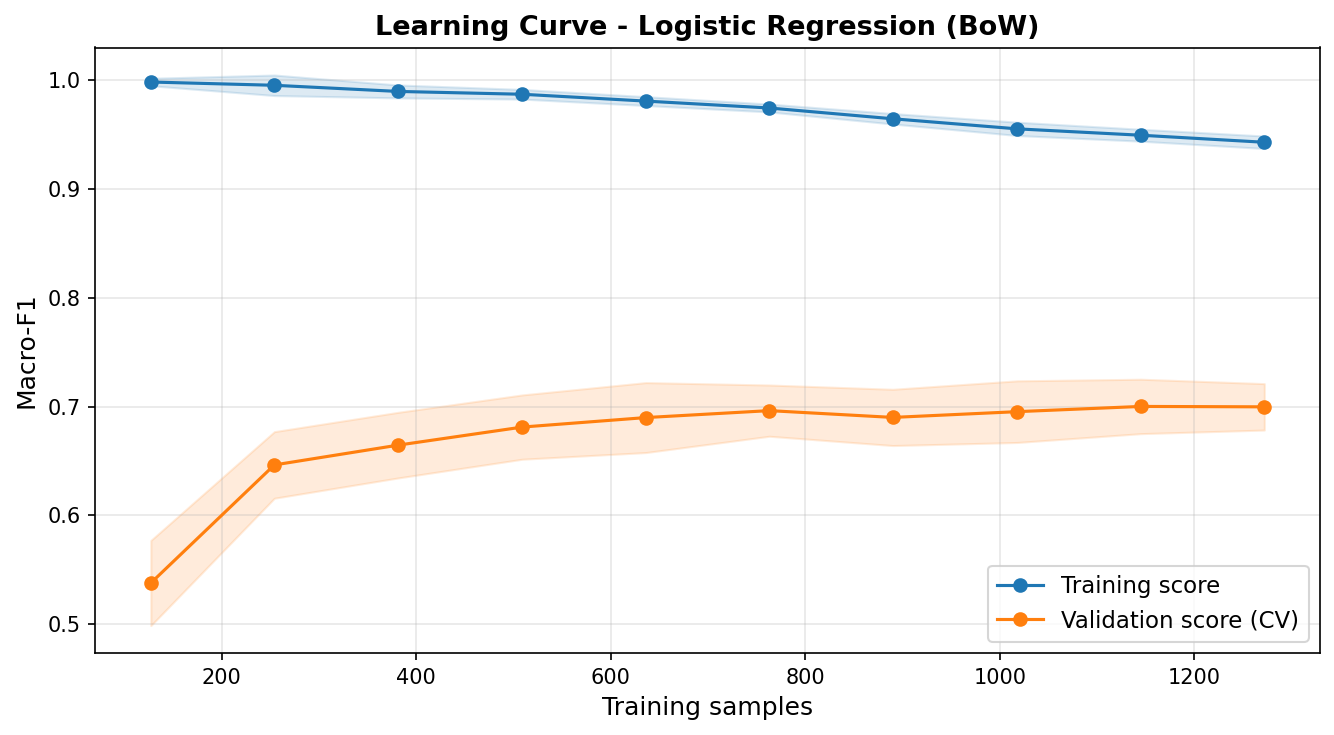


Saved to: /content/drive/MyDrive/SeaAlert/results/08_learning_curve_bow.png
Final validation Macro-F1 at full training size: 0.6997


In [15]:
print("Computing Learning Curve for Logistic Regression (BoW)...\n")

train_fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
skf_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lc_results = []

for frac in train_fractions:
    fold_train_scores = []
    fold_val_scores   = []

    for train_idx, val_idx in skf_lc.split(X, y):
        n_train  = max(int(len(train_idx) * frac), 10)
        sub_idx  = np.random.RandomState(SEED).choice(train_idx, n_train, replace=False)

        X_train, y_train = X[sub_idx],    y[sub_idx]
        X_val,   y_val   = X[val_idx],    y[val_idx]

        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
            ('clf',   LogisticRegression(max_iter=1000, random_state=SEED, C=1.0))
        ])
        pipe.fit(X_train, y_train)

        fold_train_scores.append(f1_score(y_train, pipe.predict(X_train), average='macro'))
        fold_val_scores.append(f1_score(y_val,   pipe.predict(X_val),   average='macro'))

    lc_results.append({
        'train_size':       int(len(X) * 0.8 * frac),
        'train_f1_mean':    np.mean(fold_train_scores),
        'train_f1_std':     np.std(fold_train_scores),
        'val_f1_mean':      np.mean(fold_val_scores),
        'val_f1_std':       np.std(fold_val_scores),
    })
    print(f"  Fraction {frac:.1f} | Train F1: {np.mean(fold_train_scores):.4f} | Val F1: {np.mean(fold_val_scores):.4f}")

df_lc_bow = pd.DataFrame(lc_results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_lc_bow['train_size'], df_lc_bow['train_f1_mean'], 'o-', color='#1f77b4', label='Training score')
ax.fill_between(df_lc_bow['train_size'],
                df_lc_bow['train_f1_mean'] - df_lc_bow['train_f1_std'],
                df_lc_bow['train_f1_mean'] + df_lc_bow['train_f1_std'],
                alpha=0.15, color='#1f77b4')
ax.plot(df_lc_bow['train_size'], df_lc_bow['val_f1_mean'], 'o-', color='#ff7f0e', label='Validation score (CV)')
ax.fill_between(df_lc_bow['train_size'],
                df_lc_bow['val_f1_mean'] - df_lc_bow['val_f1_std'],
                df_lc_bow['val_f1_mean'] + df_lc_bow['val_f1_std'],
                alpha=0.15, color='#ff7f0e')
ax.set_xlabel('Training samples', fontsize=12)
ax.set_ylabel('Macro-F1', fontsize=12)
ax.set_title('Learning Curve - Logistic Regression (BoW)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()

lc_bow_path = f'{base_dir}/results/08_learning_curve_bow.png'
plt.savefig(lc_bow_path, bbox_inches='tight')
plt.show()

df_lc_bow.to_csv(f'{base_dir}/results/08_learning_curve_bow.csv', index=False)
print(f"\nSaved to: {lc_bow_path}")
print(f"Final validation Macro-F1 at full training size: {df_lc_bow['val_f1_mean'].iloc[-1]:.4f}")

## Cell 8 - Learning Curve: RoBERTa

Note: This cell trains RoBERTa multiple times at different dataset sizes. Expected runtime: 2-4 hours on GPU. Run only if time permits.

Computing Learning Curve for RoBERTa...
Expected runtime: 2-4 hours on GPU.



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Macro F1
1,No log,1.721110,0.178753
2,No log,1.369491,0.302300
3,No log,1.300297,0.344271


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Macro F1
1,No log,1.778146,0.261058
2,No log,1.384721,0.263403
3,No log,1.276781,0.265855


...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Macro F1
1,1.277967,0.763379,0.690117
2,0.681909,0.684386,0.728234
3,0.485401,0.710137,0.728153


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Macro F1
1,1.296616,0.718532,0.730300
2,0.705172,0.623902,0.736568
3,0.490192,0.632321,0.756745


Fraction 1.0 | Mean F1: 0.7360 +/- 0.0148


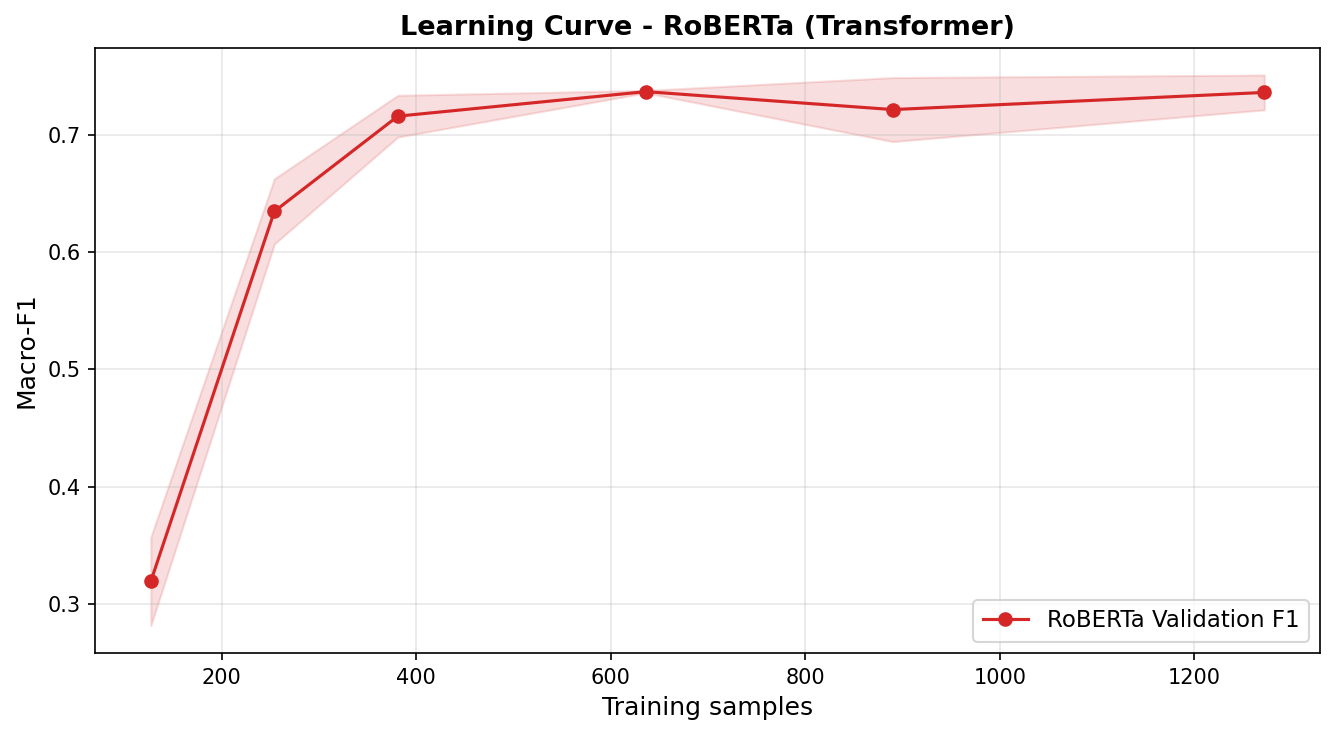

Saved to: /content/drive/MyDrive/SeaAlert/results/08_learning_curve_roberta.png


In [17]:
print("Computing Learning Curve for RoBERTa...")
print("Expected runtime: 2-4 hours on GPU.\n")

train_fractions = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
skf_lc          = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
rob_lc_results  = []

for frac in train_fractions:
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(skf_lc.split(X, y_int)):
        # Subsample training set
        n_train  = max(int(len(train_idx) * frac), 10)
        sub_idx  = np.random.choice(train_idx, n_train, replace=False)

        train_ds = SeaAlertDataset(X[sub_idx],  y_int[sub_idx],  tokenizer)
        val_ds   = SeaAlertDataset(X[val_idx],  y_int[val_idx],  tokenizer)

        model = AutoModelForSequenceClassification.from_pretrained(
            roberta_model_path, num_labels=n_labels,
            id2label=id2label, label2id=label2id,
            ignore_mismatched_sizes=True
        ).to(device)

        args = TrainingArguments(
            output_dir=f'/tmp/rob_lc_{frac}_{fold}',
            num_train_epochs=3,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            eval_strategy='epoch',
            save_strategy='no',
            learning_rate=2e-5,
            seed=SEED,
            report_to='none',
            logging_steps=50,
        )
        trainer = Trainer(
            model=model, args=args,
            train_dataset=train_ds, eval_dataset=val_ds,
            compute_metrics=compute_metrics,
        )
        trainer.train()
        metrics = trainer.evaluate()
        fold_scores.append(metrics['eval_macro_f1'])
        del model
        torch.cuda.empty_cache()

    rob_lc_results.append({
        'train_fraction': frac,
        'train_size': int(len(X) * (1 - 1/N_FOLDS) * frac),
        'val_f1_mean': np.mean(fold_scores),
        'val_f1_std':  np.std(fold_scores)
    })
    print(f"Fraction {frac:.1f} | Mean F1: {np.mean(fold_scores):.4f} +/- {np.std(fold_scores):.4f}")

df_lc_rob = pd.DataFrame(rob_lc_results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_lc_rob['train_size'], df_lc_rob['val_f1_mean'], 'o-', color='#d62728', label='RoBERTa Validation F1')
ax.fill_between(
    df_lc_rob['train_size'],
    df_lc_rob['val_f1_mean'] - df_lc_rob['val_f1_std'],
    df_lc_rob['val_f1_mean'] + df_lc_rob['val_f1_std'],
    alpha=0.15, color='#d62728'
)
ax.set_xlabel('Training samples', fontsize=12)
ax.set_ylabel('Macro-F1', fontsize=12)
ax.set_title('Learning Curve - RoBERTa (Transformer)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()

lc_rob_path = f'{results_dir}/08_learning_curve_roberta.png'
plt.savefig(lc_rob_path, bbox_inches='tight')
plt.show()
print(f"Saved to: {lc_rob_path}")

df_lc_rob.to_csv(f'{results_dir}/08_learning_curve_roberta.csv', index=False)

## Cell 9 - Combined Learning Curve Plot

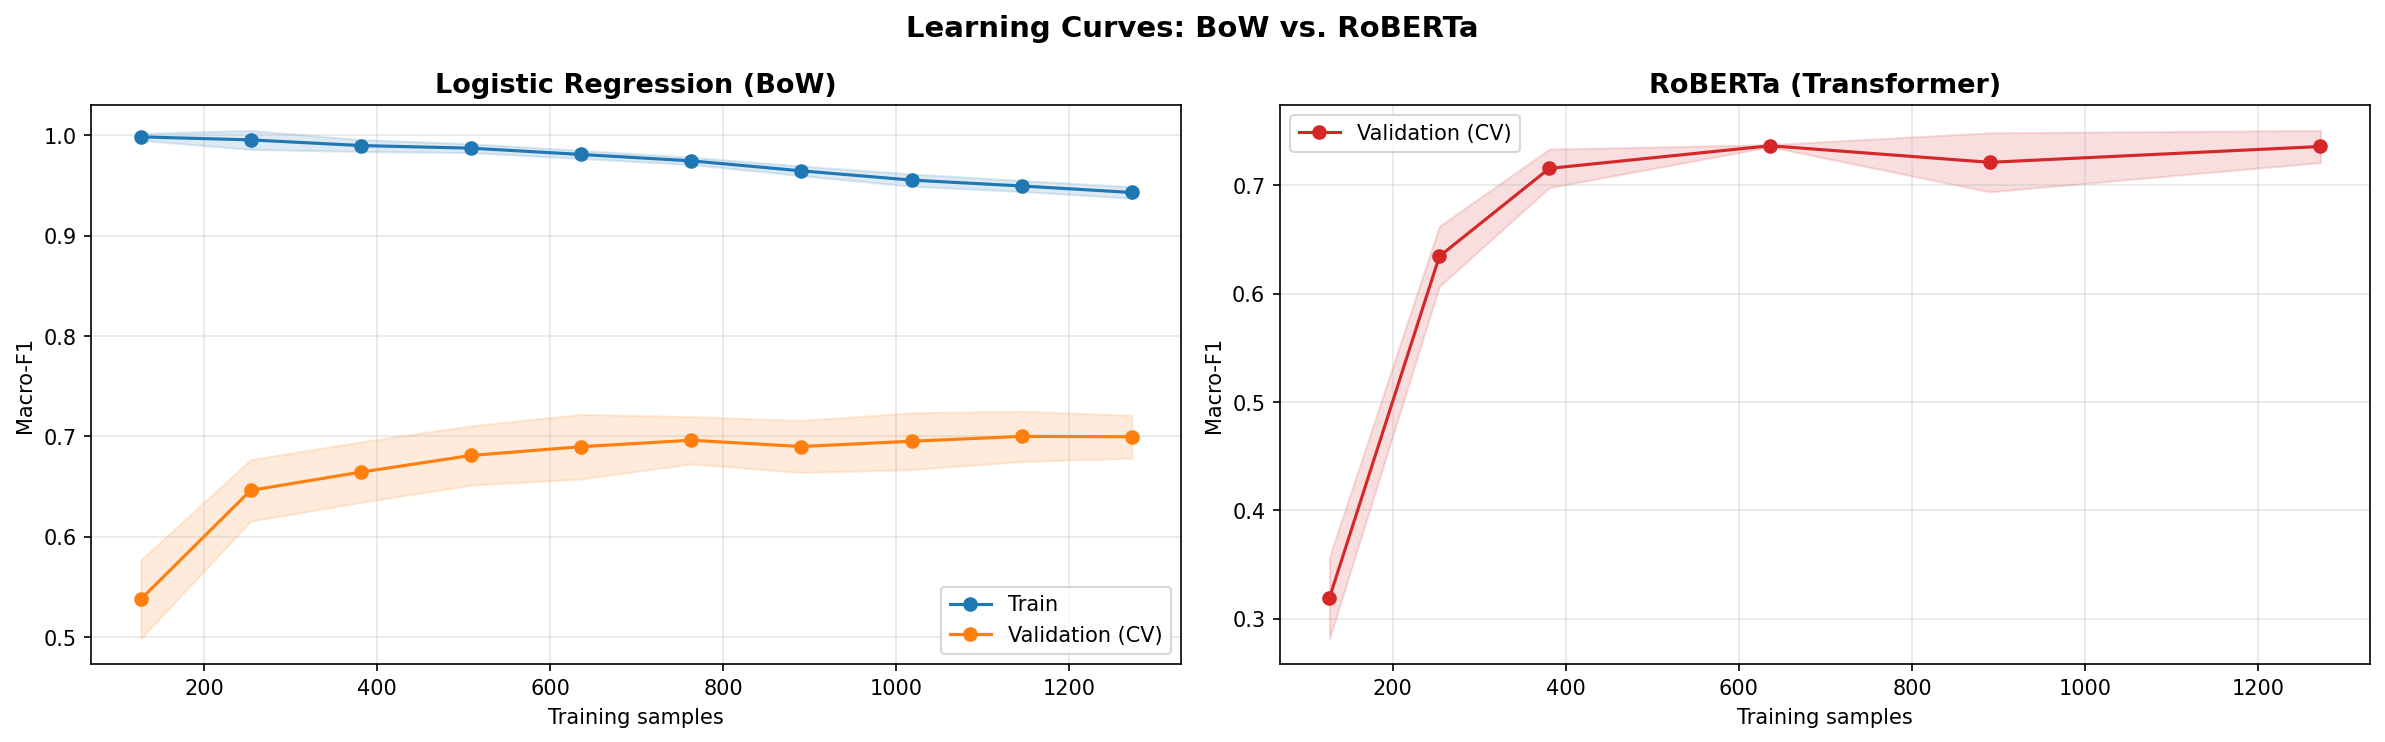

Saved to: /content/drive/MyDrive/SeaAlert/results/08_learning_curves_combined.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BoW
ax = axes[0]
ax.plot(df_lc_bow['train_size'], df_lc_bow['train_f1_mean'], 'o-', color='#1f77b4', label='Train')
ax.fill_between(df_lc_bow['train_size'],
                df_lc_bow['train_f1_mean'] - df_lc_bow['train_f1_std'],
                df_lc_bow['train_f1_mean'] + df_lc_bow['train_f1_std'],
                alpha=0.15, color='#1f77b4')
ax.plot(df_lc_bow['train_size'], df_lc_bow['val_f1_mean'], 'o-', color='#ff7f0e', label='Validation (CV)')
ax.fill_between(df_lc_bow['train_size'],
                df_lc_bow['val_f1_mean'] - df_lc_bow['val_f1_std'],
                df_lc_bow['val_f1_mean'] + df_lc_bow['val_f1_std'],
                alpha=0.15, color='#ff7f0e')
ax.set_title('Logistic Regression (BoW)', fontsize=13, fontweight='bold')
ax.set_xlabel('Training samples')
ax.set_ylabel('Macro-F1')
ax.legend()
ax.grid(alpha=0.3)

# RoBERTa
ax = axes[1]
ax.plot(df_lc_rob['train_size'], df_lc_rob['val_f1_mean'], 'o-', color='#d62728', label='Validation (CV)')
ax.fill_between(df_lc_rob['train_size'],
                df_lc_rob['val_f1_mean'] - df_lc_rob['val_f1_std'],
                df_lc_rob['val_f1_mean'] + df_lc_rob['val_f1_std'],
                alpha=0.15, color='#d62728')
ax.set_title('RoBERTa (Transformer)', fontsize=13, fontweight='bold')
ax.set_xlabel('Training samples')
ax.set_ylabel('Macro-F1')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Learning Curves: BoW vs. RoBERTa', fontsize=14, fontweight='bold')
plt.tight_layout()

combined_path = f'{base_dir}/results/08_learning_curves_combined.png'
plt.savefig(combined_path, bbox_inches='tight')
plt.show()
print(f"Saved to: {combined_path}")